# #Telecom X – Parte 2: Predicción de Cancelación (Churn)
##🧠 Objetivos del Desafío

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

##🛠️ Preparación de los Datos

In [431]:
#importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [432]:
#importar datos
datos=pd.read_csv('/content/Datos/Datos_tratados.csv')
datos.head()

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,Multiples_Lineas,Tipo_Internet,...,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Iipo_Internet,Cuentas_Diarias
0,0002-Orfbo,No,Femenino,0,Sí,Sí,9,Sí,No,Dsl,...,Sí,Sí,No,Anual,Yes,Cheque Enviado,65.6,593.30,Dsl,2.19
1,0003-Mknfe,No,Masculino,0,No,No,9,Sí,Sí,Dsl,...,No,No,Sí,Mensual,No,Cheque Enviado,59.9,542.40,Dsl,2.00
2,0004-Tlhlj,Sí,Masculino,0,No,No,4,Sí,No,Fibra Optica,...,No,No,No,Mensual,Yes,Cheque Electronico,73.9,280.85,Fiber Optic,2.46
3,0011-Igkff,Sí,Masculino,1,Sí,No,13,Sí,No,Fibra Optica,...,No,Sí,Sí,Mensual,Yes,Cheque Electronico,98.0,1237.85,Fiber Optic,3.27
4,0013-Exchz,Sí,Femenino,1,Sí,No,3,Sí,No,Fibra Optica,...,Sí,Sí,No,Mensual,Yes,Cheque Enviado,83.9,267.40,Fiber Optic,2.80


In [433]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7043 non-null   object 
 1   Evasion                 7043 non-null   object 
 2   Genero                  7043 non-null   object 
 3   Adulto_Mayor            7043 non-null   int64  
 4   Tiene_Pareja            7043 non-null   object 
 5   Tiene_Dependientes      7043 non-null   object 
 6   Meses_Contrato          7043 non-null   int64  
 7   Servicio_Telefono       7043 non-null   object 
 8   Multiples_Lineas        7043 non-null   object 
 9   Tipo_Internet           7043 non-null   object 
 10  Seguridad_Online        7043 non-null   object 
 11  Backup_Online           7043 non-null   object 
 12  Proteccion_Dispositivo  7043 non-null   object 
 13  Soporte_Tecnico         7043 non-null   object 
 14  Streaming_TV            7043 non-null   

###Eliminación de Columnas Irrelevantes

In [434]:
#Eliminar columna
datos=datos.drop(columns = ['ID_Cliente'])

In [435]:
datos

,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,Multiples_Lineas,Tipo_Internet,Seguridad_Online,...,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Iipo_Internet,Cuentas_Diarias
0,No,Femenino,0,Sí,Sí,9,Sí,No,Dsl,No,...,Sí,Sí,No,Anual,Yes,Cheque Enviado,65.60,593.30,Dsl,2.19
1,No,Masculino,0,No,No,9,Sí,Sí,Dsl,No,...,No,No,Sí,Mensual,No,Cheque Enviado,59.90,542.40,Dsl,2.00
2,Sí,Masculino,0,No,No,4,Sí,No,Fibra Optica,No,...,No,No,No,Mensual,Yes,Cheque Electronico,73.90,280.85,Fiber Optic,2.46
3,Sí,Masculino,1,Sí,No,13,Sí,No,Fibra Optica,No,...,No,Sí,Sí,Mensual,Yes,Cheque Electronico,98.00,1237.85,Fiber Optic,3.27
4,Sí,Femenino,1,Sí,No,3,Sí,No,Fibra Optica,No,...,Sí,Sí,No,Mensual,Yes,Cheque Enviado,83.90,267.40,Fiber Optic,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Femenino,0,No,No,13,Sí,No,Dsl,Sí,...,Sí,No,No,Anual,No,Cheque Enviado,55.15,742.90,Dsl,1.84
7039,Sí,Masculino,0,Sí,No,22,Sí,Sí,Fibra Optica,No,...,No,No,Sí,Mensual,Yes,Cheque Electronico,85.10,1873.70,Fiber Optic,2.84
7040,No,Masculino,0,No,No,2,Sí,No,Dsl,No,...,No,No,No,Mensual,Yes,Cheque Enviado,50.30,92.75,Dsl,1.68
7041,No,Masculino,0,Sí,Sí,67,Sí,No,Dsl,Sí,...,Sí,No,Sí,Bienal,No,Cheque Enviado,67.85,4627.65,Dsl,2.26


In [436]:
# Ver dimensiones del dataset
datos.shape

(7043, 22)

In [437]:
# Estadísticas descriptivas
datos.describe()

,Adulto_Mayor,Meses_Contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,2.158675
std,0.368612,24.559481,30.090047,2265.270398,1.003088
min,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,9.000000,35.500000,402.225000,1.180000
50%,0.000000,29.000000,70.350000,1397.475000,2.340000
75%,0.000000,55.000000,89.850000,3786.600000,2.990000
max,1.000000,72.000000,118.750000,8684.800000,3.960000


In [438]:
#evitar datos redundantes
cols_to_fix = [
    'Seguridad_Online',
    'Backup_Online',
    'Proteccion_Dispositivo',
    'Soporte_Tecnico',
    'Streaming_TV',
    'Streaming_Peliculas'
]

for col in cols_to_fix:
    datos[col] = datos[col].replace({'Sin Servicio De Internet': 'No'})

In [439]:
#Verificar valores nulos
datos.isnull().sum()

,0
Evasion,0
Genero,0
Adulto_Mayor,0
Tiene_Pareja,0
Tiene_Dependientes,0
Meses_Contrato,0
Servicio_Telefono,0
Multiples_Lineas,0
Tipo_Internet,0
Seguridad_Online,0


###Encoding

In [440]:
# Convertir variables categóricas a numéricas
datos_encoded= pd.get_dummies(datos, drop_first=True)

In [441]:
# Ver resultado
datos_encoded.head()

,Adulto_Mayor,Meses_Contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Evasion_Sí,Genero_Masculino,Tiene_Pareja_Sí,Tiene_Dependientes_Sí,Servicio_Telefono_Sí,...,Streaming_TV_Sí,Streaming_Peliculas_Sí,Tipo_Contrato_Bienal,Tipo_Contrato_Mensual,Factura_Digital_Yes,Metodo_Pago_Cheque Enviado,Metodo_Pago_Tarjeta De Crédito (Automático),Metodo_Pago_Transferencia Bancaria (Automática),Iipo_Internet_Fiber Optic,Iipo_Internet_No
0,0,9,65.6,593.30,2.19,False,False,True,True,True,...,True,False,False,False,True,True,False,False,False,False
1,0,9,59.9,542.40,2.00,False,True,False,False,True,...,False,True,False,True,False,True,False,False,False,False
2,0,4,73.9,280.85,2.46,True,True,False,False,True,...,False,False,False,True,True,False,False,False,True,False
3,1,13,98.0,1237.85,3.27,True,True,True,False,True,...,True,True,False,True,True,False,False,False,True,False
4,1,3,83.9,267.40,2.80,True,False,True,False,True,...,True,False,False,True,True,True,False,False,True,False


###Verificación de la Proporción de Cancelación (Churn)
Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos.

In [442]:
# Conteo de clases
datos_encoded['Evasion_Sí'].value_counts()

,count
Evasion_Sí,
False,5174
True,1869


In [443]:
# Proporción de evasion
datos_encoded['Evasion_Sí'].value_counts(normalize=True)*100

,proportion
Evasion_Sí,
False,73.463013
True,26.536987


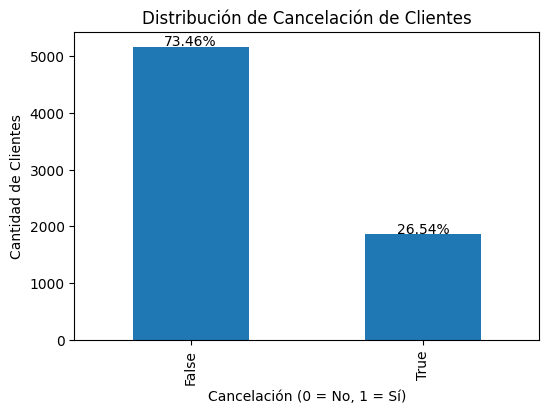

In [444]:
conteo = datos_encoded['Evasion_Sí'].value_counts()
porcentaje = datos_encoded['Evasion_Sí'].value_counts(normalize=True) * 100
plt.figure(figsize=(6,4))
ax = conteo.plot(kind='bar')

for i, v in enumerate(conteo):
    plt.text(i, v + 10, f'{porcentaje.iloc[i]:.2f}%', ha='center')

plt.title("Distribución de Cancelación de Clientes")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de Clientes")
plt.show()

###Normalización

In [445]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Ajustar y transformar los datos
X_scaled = scaler.fit_transform(X)
# Convertir nuevamente a DataFrame para mantener los nombres de columnas
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Adulto_Mayor,Meses_Contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Genero_Masculino,Tiene_Pareja_Sí,Tiene_Dependientes_Sí,Servicio_Telefono_Sí,Multiples_Lineas_Sin Servicio De Teléfono,...,Streaming_TV_Sí,Streaming_Peliculas_Sí,Tipo_Contrato_Bienal,Tipo_Contrato_Mensual,Factura_Digital_Yes,Metodo_Pago_Cheque Enviado,Metodo_Pago_Tarjeta De Crédito (Automático),Metodo_Pago_Transferencia Bancaria (Automática),Iipo_Internet_Fiber Optic,Iipo_Internet_No
0,-0.439916,-0.951682,0.027862,-0.745490,0.031231,-1.009559,1.034530,1.529024,0.327438,-0.327438,...,1.265612,-0.796070,-0.562975,-1.105970,0.829798,1.835513,-0.525047,-0.529885,-0.885660,-0.525927
1,-0.439916,-0.951682,-0.161583,-0.767961,-0.158198,0.990532,-0.966622,-0.654012,0.327438,-0.327438,...,-0.790132,1.256171,-0.562975,0.904184,-1.205113,1.835513,-0.525047,-0.529885,-0.885660,-0.525927
2,-0.439916,-1.155283,0.303720,-0.883431,0.300419,0.990532,-0.966622,-0.654012,0.327438,-0.327438,...,-0.790132,-0.796070,-0.562975,0.904184,0.829798,-0.544807,-0.525047,-0.529885,1.129102,-0.525927
3,2.273159,-0.788800,1.104706,-0.460934,1.107982,0.990532,1.034530,-0.654012,0.327438,-0.327438,...,1.265612,1.256171,-0.562975,0.904184,0.829798,-0.544807,-0.525047,-0.529885,1.129102,-0.525927
4,2.273159,-1.196004,0.636080,-0.889368,0.639396,-1.009559,1.034530,-0.654012,0.327438,-0.327438,...,1.265612,-0.796070,-0.562975,0.904184,0.829798,1.835513,-0.525047,-0.529885,1.129102,-0.525927


##🎯 Correlación y Selección de Variables

###Análisis de Correlación

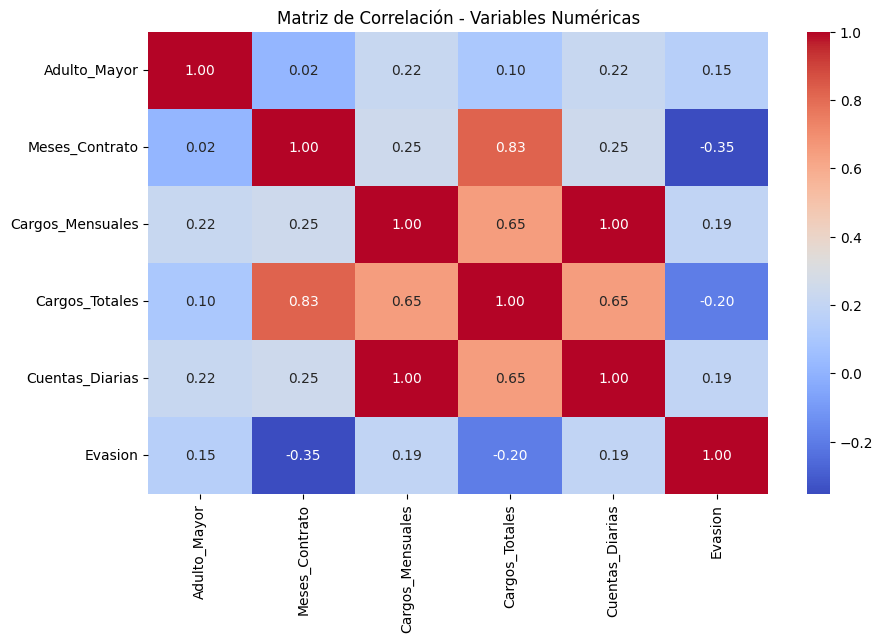

In [446]:
# Análisis de correlación
# Correlación entre variables numéricas
import matplotlib.pyplot as plt
import seaborn as sns

datos_corr = datos.select_dtypes(include=["int64", "float64"])
datos_corr["Evasion"] = datos["Evasion"].map({"Sí": 1, "No": 0})
corr_matrix = datos_corr.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matriz de Correlación - Variables Numéricas")
plt.show()

In [447]:
datos_corr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Adulto_Mayor      7043 non-null   int64  
 1   Meses_Contrato    7043 non-null   int64  
 2   Cargos_Mensuales  7043 non-null   float64
 3   Cargos_Totales    7043 non-null   float64
 4   Cuentas_Diarias   7043 non-null   float64
 5   Evasion           7043 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 330.3 KB


###Análisis Dirigido

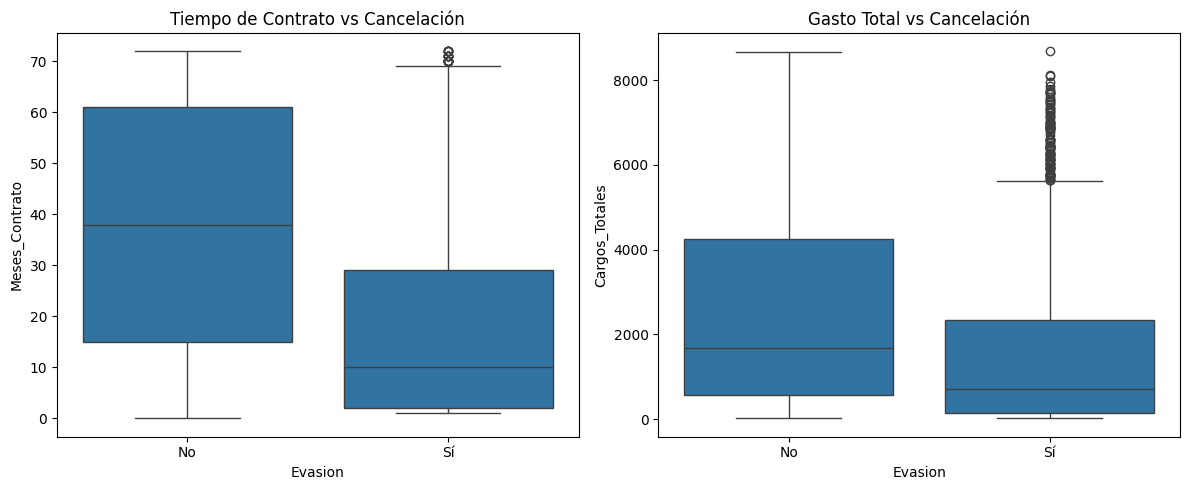

In [448]:
# Análisis dirigido: relación entre variables y cancelación
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x="Evasion", y="Meses_Contrato", data=datos)
plt.title("Tiempo de Contrato vs Cancelación")

plt.subplot(1,2,2)
sns.boxplot(x="Evasion", y="Cargos_Totales", data=datos)
plt.title("Gasto Total vs Cancelación")

plt.tight_layout()
plt.show()

In [449]:
# Eliminación de variables redundantes
# Se eliminan las columnas Cargos_Diarios y Cargos_Totales porque están altamente relacionadas con otras variables como Cargos_Mensuales y
# Meses_Contrato. Mantenerlas podría generar redundancia en el modelo.

datos = datos.drop(columns=["Cuentas_Diarias", "Cargos_Totales"])

##🤖 Modelado Predictivo

###Separación de Datos
Para evaluar correctamente el rendimiento del modelo, es necesario dividir el conjunto de datos en datos de entrenamiento y datos de prueba.

Entrenamiento (70%): se utilizan para que el modelo aprenda los patrones de los datos.

In [450]:
X = datos_encoded.drop('Evasion_Sí', axis=1)
y = datos_encoded['Evasion_Sí']

In [451]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

###Creación de Modelos

Modelo1 - Regresión Logística: En esta sección entrenamos un modelo de Regresión Logística para predecir la cancelación de clientes (evasion).

In [452]:
#Normalizar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [453]:
#Entrenar Regresión Logística
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Regresión Logística")
print(classification_report(y_test, y_pred_log))

Regresión Logística
              precision    recall  f1-score   support

       False       0.84      0.89      0.86      1035
        True       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



Modelo2 - Random Forest: En esta sección entrenamos un modelo de Random Forest para predecir la cancelación de clientes (evasion).

In [454]:
# Crear el modelo Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1035
        True       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



###Evaluación de los Modelos

*Los modelos evaluados son:*
*    Regresión Logística
*    Random Forest

*Las métricas utilizadas son:*

*  Exactitud (Accuracy)
*  Precisión (Precision)
*  Recall
*  F1-score
*  Matriz de confusión

1. Modelo de Regresión Logística

In [455]:
# Evaluación del modelo de Regresión Logística
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Evaluación - Regresión Logística")
accuracy_log = accuracy_score(y_test, y_pred_log)
print("Accuracy:", accuracy_log)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_log))
cm_log = confusion_matrix(y_test, y_pred_log)
print("\nMatriz de Confusión:")
print(cm_log)

Evaluación - Regresión Logística
Accuracy: 0.794180269694819

Reporte de Clasificación:
              precision    recall  f1-score   support

       False       0.84      0.89      0.86      1035
        True       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


Matriz de Confusión:
[[924 111]
 [179 195]]


In [456]:
# Evaluación del modelo de Regresión Logística Balanceada
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
log_balanced.fit(X_train_scaled, y_train)
y_pred_log_bal = log_balanced.predict(X_test_scaled)

print("Regresión Logística Balanceada")
print(classification_report(y_test, y_pred_log_bal))

Regresión Logística Balanceada
              precision    recall  f1-score   support

       False       0.90      0.72      0.80      1035
        True       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



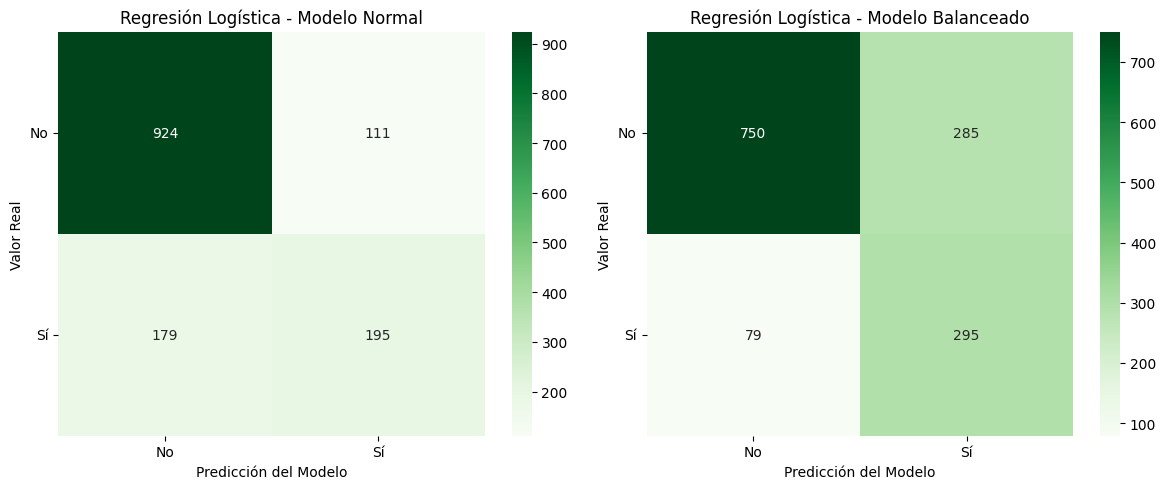

In [457]:
#Evaluación del modelo
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)
cm_log_bal = confusion_matrix(y_test, y_pred_log_bal)
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Regresión Logística Normal
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[0],
    cbar=True
)

axes[0].set_title("Regresión Logística - Modelo Normal")
axes[0].set_xlabel("Predicción del Modelo")
axes[0].set_ylabel("Valor Real")
axes[0].set_xticklabels(["No", "Sí"])
axes[0].set_yticklabels(["No", "Sí"], rotation=0)

# Regresión Logística Balanceada
sns.heatmap(
    cm_log_bal,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1],
    cbar=True
)

axes[1].set_title("Regresión Logística - Modelo Balanceado")
axes[1].set_xlabel("Predicción del Modelo")
axes[1].set_ylabel("Valor Real")
axes[1].set_xticklabels(["No", "Sí"])
axes[1].set_yticklabels(["No", "Sí"], rotation=0)

plt.tight_layout()
plt.show()

2. Modelo Random Forest

In [458]:
#Evaluación del modelo Random Forest
print("Evaluación - Random Forest")
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nMatriz de Confusión:")
print(cm_rf)

Evaluación - Random Forest
Accuracy: 0.7828246983676366

Reporte de Clasificación:
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1035
        True       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409


Matriz de Confusión:
[[925 110]
 [196 178]]


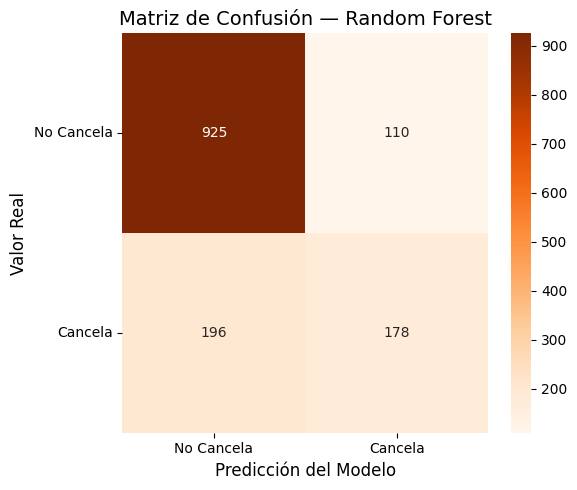

In [459]:
# Calcular matriz de confusión
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=True
)

plt.title("Matriz de Confusión — Random Forest", fontsize=14)
plt.xlabel("Predicción del Modelo", fontsize=12)
plt.ylabel("Valor Real", fontsize=12)
plt.xticks([0.5,1.5], ["No Cancela", "Cancela"])
plt.yticks([0.5,1.5], ["No Cancela", "Cancela"], rotation=0)
plt.tight_layout()
plt.show()

##📋 Interpretación y Conclusiones

###Regresión Logística

En la Regresión Logística, cada variable tiene un coeficiente que indica su influencia en la predicción.

Coeficiente positivo → aumenta la probabilidad de cancelación

Coeficiente negativo → reduce la probabilidad de cancelación

In [460]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_model.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)
coeficientes.head(10)

,Variable,Coeficiente
3,Cargos_Totales,0.660311
20,Tipo_Contrato_Mensual,0.342668
11,Tipo_Internet_Fibra Optica,0.308300
25,Iipo_Internet_Fiber Optic,0.308300
17,Streaming_TV_Sí,0.213171
10,Multiples_Lineas_Sí,0.202313
21,Factura_Digital_Yes,0.178377
18,Streaming_Peliculas_Sí,0.161193
0,Adulto_Mayor,0.072320
15,Proteccion_Dispositivo_Sí,0.034690


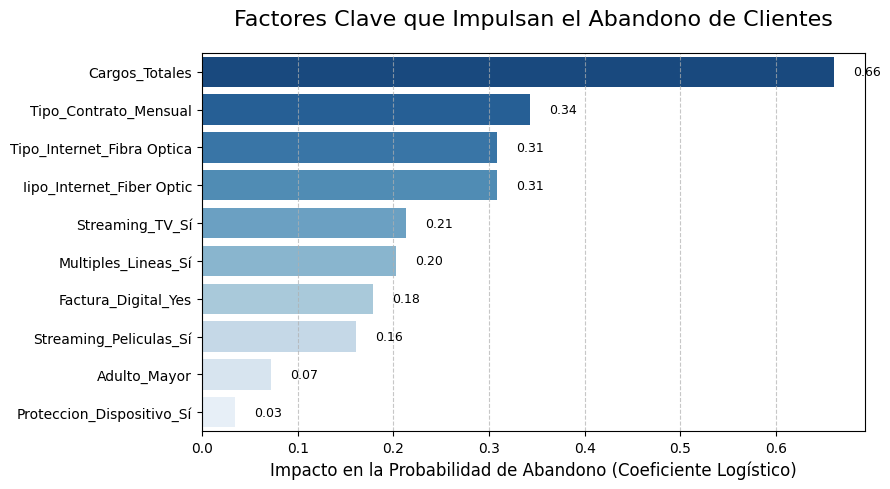

In [461]:
import seaborn as sns
import matplotlib.pyplot as plt

top_positive = coeficientes.head(10)
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x="Coeficiente",
    y="Variable",
    data=top_positive,
    palette="Blues_r",
    hue="Variable",
    legend=False
)
plt.title("Factores Clave que Impulsan el Abandono de Clientes", fontsize=16, pad=20)
plt.xlabel("Impacto en la Probabilidad de Abandono (Coeficiente Logístico)", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 0.02,
        p.get_y() + p.get_height() / 2,
        f'{width:.2f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

###Random Forest

La importancia se basa en cuánto ayuda cada variable a reducir la impureza en los árboles de decisión.

In [462]:
#Importancia de variables — Random Forest
importances = rf_model.feature_importances_

rf_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": importances
})
rf_importance = rf_importance.sort_values(by="Importancia", ascending=False)
rf_importance.head(10)

,Variable,Importancia
3,Cargos_Totales,0.168584
1,Meses_Contrato,0.152160
2,Cargos_Mensuales,0.135539
4,Cuentas_Diarias,0.112599
20,Tipo_Contrato_Mensual,0.073225
11,Tipo_Internet_Fibra Optica,0.029849
5,Genero_Masculino,0.025065
21,Factura_Digital_Yes,0.023728
25,Iipo_Internet_Fiber Optic,0.022198
6,Tiene_Pareja_Sí,0.020817


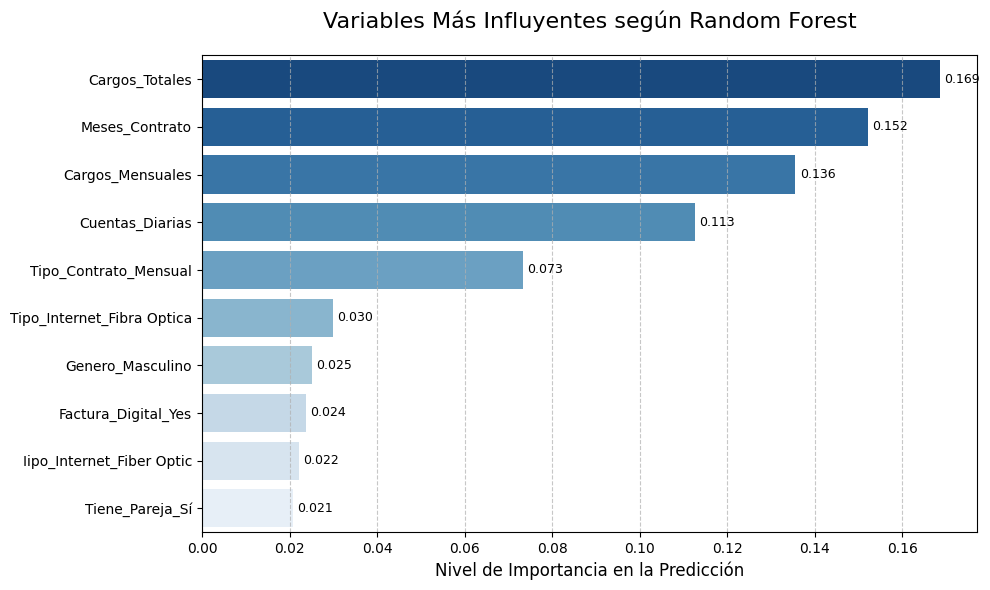

In [463]:
top_rf = rf_importance.head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x="Importancia",
    y="Variable",
    data=top_rf,
    palette="Blues_r",
    hue="Variable",
    legend=False
)

plt.title("Variables Más Influyentes según Random Forest", fontsize=16, pad=20)
plt.xlabel("Nivel de Importancia en la Predicción", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.7)

for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 0.001,
        p.get_y() + p.get_height() / 2,
        f'{width:.3f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

##Conclusión

1. Objetivo del Análisis

El objetivo principal de este estudio fue identificar los factores que influyen en la cancelación de clientes (churn) en la empresa Telecom X, utilizando técnicas de análisis de datos y modelos de aprendizaje automático.



2. Preparación y Análisis de los Datos

Durante la etapa inicial se realizó la limpieza y transformación del conjunto de datos, lo cual incluyó:

*   Eliminación de columnas irrelevantes como el identificador del cliente.

*   Codificación de variables categóricas para convertirlas en valores numéricos.

*   Normalización de variables numéricas para mejorar el rendimiento de los modelos.

*  Análisis de correlación entre variables.

Además, se analizó la proporción de cancelación de clientes, encontrando que aproximadamente:

*  73% de los clientes permanecen activos

*  27% de los clientes cancelan el servicio

3. Modelado Predictivo

Para predecir la cancelación de clientes se implementaron dos modelos de clasificación:

*  Regresión Logística

*  Random Forest

Estos modelos permiten analizar patrones en los datos y estimar la probabilidad de que un cliente decida cancelar el servicio.

Los resultados obtenidos muestran que los modelos presentan niveles de precisión entre aproximadamente 74% y 78%, lo que indica que son capaces de identificar correctamente una gran parte de los casos de cancelación.

El Random Forest presentó el mayor nivel de precisión general, mostrando una buena capacidad para clasificar correctamente a los clientes que permanecen o cancelan el servicio.

4. Factores que Influyen en la Cancelación de Clientes

A partir del análisis de importancia de variables realizado con Regresión Logística y Random Forest, se identificaron los principales factores que influyen en la cancelación de clientes.

Entre los factores más relevantes se encuentran:

*  Cargos Totales

*  Duración del contrato (Meses de contrato)

*  Cargos mensuales

*  Tipo de contrato mensual

*  Tipo de servicio de internet (especialmente fibra óptica)

*  Cantidad de líneas o servicios adicionales

Estos resultados indican que los clientes con contratos mensuales, altos costos de servicio o menor tiempo de permanencia tienden a cancelar con mayor frecuencia.

5. Estrategias de Retención Basadas en los Resultados

A partir de los factores identificados, se pueden proponer algunas estrategias que la empresa podría implementar para reducir la cancelación de clientes:

*  Incentivar contratos a largo plazo: Ofrecer descuentos o beneficios a clientes que cambien de contratos mensuales a contratos anuales o de mayor duración.

*   Revisar los precios de los servicios: Dado que los cargos mensuales y totales influyen en la cancelación, se podrían ofrecer planes más flexibles o promociones para clientes con mayor riesgo de abandono.

*   Mejorar la experiencia del servicio de internet: Los clientes con ciertos tipos de servicios de internet presentan mayor probabilidad de cancelar, por lo que mejorar la calidad del servicio podría reducir el churn.

*  Uso de modelos predictivos en la empresa: Los modelos desarrollados en este proyecto podrían implementarse para identificar clientes con alto riesgo de cancelación, permitiendo a la empresa actuar de forma preventiva.